# 🔬 Manufacturing Intelligence Atlas: Web Scraping & Data Pipeline
### Automated Extraction of Market Metrics, Industry Signals & Research Literature

This interactive notebook demonstrates how the **`seed`** corpus and **`metrics`** data in `lib/corpus.ts` are acquired, normalized, and validated through web scraping and API ingestion.

Author: Kevin Siswandi

---

### Pipeline Workflow Overview
1. **Ethical Bounded Fetcher & Robots.txt**: Safe HTTP client with domain allowlists, size limits, redirect protection, and robots checks.
2. **Market Report Scraping & Regex Extraction (`woh-market`)**: Scraping public market releases (Wohlers Report) and parsing:
   - **Global Revenue**: `$24.2B` (+10.9% YoY)
   - **Segment Distribution**: Printing Services (48%), Systems & Servicing (26%), Materials (20%), Software (6%)
   - **Regional Growth Rates**: Asia-Pacific (19.8%), Americas (12.6%), EMEA (9.0%)
3. **Industry Perspectives & Insights (`woh-method`, `woh-insights`)**: Scraping market intelligence strategy and report indices.
4. **Government Standards & Qualification (`nist-*`)**: Scraping NIST additive manufacturing qualification and materials science portals.
5. **Scholarly Literature Enrichment**: Ingesting live peer-reviewed works via the **Crossref REST API**.
6. **Data Integrity & Fingerprinting**: SHA-256 content hashing and attribution filtering.
7. **Export & Validation**: Formatting into `corpus.ts`-compatible JSON / TypeScript and rendering analytical charts.

In [1]:
# Setup & Dependency Installation
# Run this cell if executing in Google Colab or a fresh Python environment
# !pip install requests beautifulsoup4 pandas matplotlib tabulate

import urllib.request
import urllib.robotparser
import urllib.error
from urllib.parse import urlparse, urljoin
import json
import re
import hashlib
import time
from datetime import datetime, timezone
from typing import Dict, List, Optional, Any

print("✓ Standard library environment ready for data collection.")

✓ Standard library environment ready for data collection.


## 1. Ethical & Bounded Fetching Architecture

Production web scraping requires safeguards to avoid hitting server rate limits, downloading multi-gigabyte payloads, or triggering infinite redirect loops.

Below is the Python equivalent of `boundedFetch` and `permitted` from `corpus.ts`:
- **Domain Allowlist**: Only permitted domains (`wohlersassociates.com`, `nist.gov`, `api.crossref.org`).
- **Payload Limit**: Aborts if response exceeds 1.5 MB (`1,500,000` bytes).
- **Timeout**: Strict 10-second timeout.
- **Robots.txt Parser**: Respects disallow directives.

In [2]:
ALLOWED_DOMAINS = {
    "wohlersassociates.com",
    "platform.wohlersassociates.com",
    "www.nist.gov",
    "nist.gov",
    "api.crossref.org"
}

USER_AGENT = "ManufacturingAtlasResearchDemo/1.0 (+https://manufacturing-atlas.demo; market-research)"
MAX_BYTES = 1_500_000  # 1.5MB bounded limit
TIMEOUT_SECS = 10

class BoundedFetcher:
    """
    Safe HTTP scraper with bounded memory consumption and domain allowlisting.
    """
    def __init__(self, allowed_domains=ALLOWED_DOMAINS, user_agent=USER_AGENT):
        self.allowed = allowed_domains
        self.user_agent = user_agent
        self.robots_cache: Dict[str, urllib.robotparser.RobotFileParser] = {}

    def is_domain_allowed(self, url: str) -> bool:
        parsed = urlparse(url)
        return parsed.hostname in self.allowed

    def is_permitted_by_robots(self, url: str) -> bool:
        parsed = urlparse(url)
        origin = f"{parsed.scheme}://{parsed.netloc}"
        
        if origin not in self.robots_cache:
            rp = urllib.robotparser.RobotFileParser()
            robots_url = f"{origin}/robots.txt"
            try:
                req = urllib.request.Request(robots_url, headers={"User-Agent": self.user_agent})
                with urllib.request.urlopen(req, timeout=5) as resp:
                    rp.parse(resp.read().decode('utf-8', errors='ignore').splitlines())
            except Exception:
                # Default to permissive if robots.txt returns 404
                rp.allow_all = True
            self.robots_cache[origin] = rp
        
        rp = self.robots_cache[origin]
        return getattr(rp, 'allow_all', False) or rp.can_fetch(self.user_agent, url)

    def fetch(self, url: str) -> str:
        if not self.is_domain_allowed(url):
            raise ValueError(f"Domain not in allowlist: {urlparse(url).hostname}")
            
        if not self.is_permitted_by_robots(url):
            raise PermissionError(f"URL disallowed by robots.txt: {url}")
            
        req = urllib.request.Request(url, headers={
            "User-Agent": self.user_agent,
            "Accept": "text/html,application/json;q=0.9,*/*;q=0.8"
        })
        
        with urllib.request.urlopen(req, timeout=TIMEOUT_SECS) as resp:
            total_bytes = 0
            chunks = []
            while True:
                chunk = resp.read(65536)  # 64KB chunk
                if not chunk:
                    break
                total_bytes += len(chunk)
                if total_bytes > MAX_BYTES:
                    raise ValueError(f"Page size exceeded limit ({MAX_BYTES} bytes)")
                chunks.append(chunk)
                
            charset = resp.headers.get_content_charset() or 'utf-8'
            return b''.join(chunks).decode(charset, errors='replace')

fetcher = BoundedFetcher()
print("✓ BoundedFetcher initialized with allowlists and size limits.")

✓ BoundedFetcher initialized with allowlists and size limits.


## 2. Text Extraction & Cleaning (`cleanHtml` & Attribution Filtering)

Raw HTML contains navigation bars, footers, scripts, and trackers. We isolate the primary `<article>` or `<main>` element and clean out boilerplate tags.

In [3]:
def clean_html(html: str) -> str:
    """
    Extracts article or main body content and strips script/style tags and HTML entities.
    """
    # Try extracting <article> or <main> container
    article_match = re.search(r'<article\b[^>]*>(.*?)</article>', html, re.DOTALL | re.IGNORECASE)
    main_match = re.search(r'<main\b[^>]*>(.*?)</main>', html, re.DOTALL | re.IGNORECASE)
    content = (article_match.group(1) if article_match else None) or (main_match.group(1) if main_match else None) or html
    
    # Remove scripts, styles, navigations, footers
    content = re.sub(r'<(script|style|nav|header|footer|noscript)\b[^>]*>.*?</\1>', ' ', content, flags=re.DOTALL | re.IGNORECASE)
    # Strip HTML tags
    content = re.sub(r'<[^>]+>', ' ', content)
    # Decode common HTML entities
    content = content.replace('&nbsp;', ' ').replace('&#160;', ' ').replace('&amp;', '&').replace('&quot;', '"')
    content = content.replace('&#39;', "'").replace('&apos;', "'").replace('&lt;', '<').replace('&gt;', '>')
    # Normalize whitespace
    clean_text = re.sub(r'\s+', ' ', content).strip()
    return clean_text


def compute_sha256(text: str) -> str:
    """Generates hexadecimal SHA-256 fingerprint of the cleaned text."""
    return hashlib.sha256(text.encode('utf-8')).hexdigest()

print("✓ HTML cleaning and fingerprinting utilities loaded.")

✓ HTML cleaning and fingerprinting utilities loaded.


## 3. Scraping & Parsing the Wohlers 2026 Market Baseline (`woh-market`)

### Extracting Quantitative Metrics via Regex
The Wohlers Report 2026 press release includes specific numerical metrics on total revenue, growth rates, segment shares, and regional averages. 

Below we define the regex pattern extractors to turn the unstructured press release text into the structured `metrics` object.

In [4]:
def parse_wohlers_market_metrics(text: str) -> Dict[str, Any]:
    """
    Extracts quantitative baseline metrics from Wohlers public report release text.
    """
    metrics = {
        "year": 2025,
        "revenue": None,
        "growth": None,
        "segments": [],
        "regions": [],
        "sourceId": "woh-market",
        "period": "2025",
        "scope": "Global additive manufacturing",
        "units": "USD billions; percent",
        "method": "Public report-release figures; regional growth is average company revenue growth."
    }
    
    # 1. Total Market Revenue ($24.2 billion)
    rev_match = re.search(r'\$(\d+(?:\.\d+)?)\s*billion', text, re.IGNORECASE)
    if rev_match:
        metrics["revenue"] = float(rev_match.group(1))
        
    # 2. Overall YoY Growth (up 10.9%)
    growth_match = re.search(r'(?:up|grew|growth of)\s*(\d+(?:\.\d+)?)\s*%', text, re.IGNORECASE)
    if growth_match:
        metrics["growth"] = float(growth_match.group(1))
        
    # 3. Market Segments
    # e.g.: printing services 48%, systems and servicing 26%, materials 20%, software 6%
    seg_patterns = [
        ("Printing services", r'printing services\s*(\d+(?:\.\d+)?)\s*%'),
        ("Systems & servicing", r'systems (?:and|&)? servicing\s*(\d+(?:\.\d+)?)\s*%'),
        ("Materials", r'materials\s*(\d+(?:\.\d+)?)\s*%'),
        ("Software", r'software\s*(\d+(?:\.\d+)?)\s*%')
    ]
    
    for name, pattern in seg_patterns:
        m = re.search(pattern, text, re.IGNORECASE)
        if m:
            metrics["segments"].append({"name": name, "share": float(m.group(1))})
            
    # 4. Regional Momentum
    # e.g.: Asia-Pacific 19.8%, Americas 12.6%, EMEA 9.0%
    reg_patterns = [
        ("Asia-Pacific", r'Asia[- ]Pacific\s*(\d+(?:\.\d+)?)\s*%'),
        ("Americas", r'Americas\s*(\d+(?:\.\d+)?)\s*%'),
        ("EMEA", r'EMEA\s*(\d+(?:\.\d+)?)\s*%')
    ]
    
    for name, pattern in reg_patterns:
        m = re.search(pattern, text, re.IGNORECASE)
        if m:
            metrics["regions"].append({"name": name, "growth": float(m.group(1))})
            
    return metrics

# Demonstrate parser on the Wohlers 2026 press release text
sample_wohlers_text = (
    "Global additive manufacturing revenue reached $24.2 billion in 2025, up 10.9%. "
    "Revenue shares: printing services 48%, systems and servicing 26%, materials 20%, software 6%. "
    "Services grew 15.5%; system sales grew 3.6%. Average company revenue growth: "
    "Asia-Pacific 19.8%, Americas 12.6%, EMEA 9.0%. These regional measures are company averages, "
    "not market shares. The public release describes an industry focused on utilization and production outcomes."
)

extracted_metrics = parse_wohlers_market_metrics(sample_wohlers_text)
print("Extracted Metrics from Scraped Wohlers Text:")
print(json.dumps(extracted_metrics, indent=2))

Extracted Metrics from Scraped Wohlers Text:
{
  "year": 2025,
  "revenue": 24.2,
  "growth": 10.9,
  "segments": [
    {
      "name": "Printing services",
      "share": 48.0
    },
    {
      "name": "Systems & servicing",
      "share": 26.0
    },
    {
      "name": "Materials",
      "share": 20.0
    },
    {
      "name": "Software",
      "share": 6.0
    }
  ],
  "regions": [
    {
      "name": "Asia-Pacific",
      "growth": 19.8
    },
    {
      "name": "Americas",
      "growth": 12.6
    },
    {
      "name": "EMEA",
      "growth": 9.0
    }
  ],
  "sourceId": "woh-market",
  "period": "2025",
  "scope": "Global additive manufacturing",
  "units": "USD billions; percent",
  "method": "Public report-release figures; regional growth is average company revenue growth."
}


## 4. Scraping NIST Research Standards (`nist-qualification`, `nist-materials`, `nist-am`)

NIST is an authoritative, public-domain source for additive manufacturing measurement science and qualification benchmarks. Below, we fetch and clean real data from NIST.

In [5]:
nist_sources_to_scrape = [
    {
        "id": "nist-qualification",
        "title": "Qualification of AM materials, processes, and parts",
        "publisher": "NIST",
        "url": "https://www.nist.gov/programs-projects/qualification-additive-manufacturing-materials-processes-and-parts",
        "topic": "Qualification",
        "kind": "Research"
    },
    {
        "id": "nist-materials",
        "title": "Materials science for additive manufacturing",
        "publisher": "NIST",
        "url": "https://www.nist.gov/additive-manufacturing/our-team/material-measurement-laboratory",
        "topic": "Materials",
        "kind": "Research"
    },
    {
        "id": "nist-am",
        "title": "Additive manufacturing research at NIST",
        "publisher": "NIST",
        "url": "https://www.nist.gov/additive-manufacturing",
        "topic": "Advanced manufacturing",
        "kind": "Research"
    }
]

scraped_nist_records = []

for item in nist_sources_to_scrape:
    print(f"Fetching NIST source: {item['title']}...")
    try:
        html = fetcher.fetch(item["url"])
        cleaned = clean_html(html)
        # Extract first 400 chars as excerpt
        summary = cleaned[:400] + ("..." if len(cleaned) > 400 else "")
        fingerprint = compute_sha256(cleaned)
        
        record = {
            "id": item["id"],
            "title": item["title"],
            "publisher": item["publisher"],
            "url": item["url"],
            "topic": item["topic"],
            "date": None,
            "fetchedAt": datetime.now(timezone.utc).isoformat(),
            "text": summary,
            "status": "live",
            "kind": item["kind"],
            "hash": fingerprint
        }
        scraped_nist_records.append(record)
        print(f"  ✓ Scraped {len(cleaned)} chars. SHA-256: {fingerprint[:12]}...")
    except Exception as e:
        print(f"  ⚠ Fetch error: {e}. Falling back to baseline record.")
        record = {
            "id": item["id"],
            "title": item["title"],
            "publisher": item["publisher"],
            "url": item["url"],
            "topic": item["topic"],
            "date": None,
            "fetchedAt": None,
            "text": f"NIST {item['topic']} research focuses on measurement science, standards, and qualification protocols.",
            "status": "baseline",
            "kind": item["kind"]
        }
        scraped_nist_records.append(record)
        
print(f"\nCompleted NIST collection: {len(scraped_nist_records)} records acquired.")

Fetching NIST source: Qualification of AM materials, processes, and parts...
  ✓ Scraped 8114 chars. SHA-256: b71827383ff6...
Fetching NIST source: Materials science for additive manufacturing...
  ✓ Scraped 6373 chars. SHA-256: 43ca2e903026...
Fetching NIST source: Additive manufacturing research at NIST...
  ✓ Scraped 2314 chars. SHA-256: c3668a0d4392...

Completed NIST collection: 3 records acquired.


## 5. Live Scholarly Research Enrichment: Crossref REST API

The data pipeline pairs scraped industry websites with scholarly bibliographic records from the **Crossref API**. This provides real-time verification of peer-reviewed literature.

In [6]:
def fetch_crossref_am_literature(rows: int = 5) -> List[Dict[str, Any]]:
    """
    Queries Crossref REST API for recently published peer-reviewed additive manufacturing articles.
    """
    today = datetime.now(timezone.utc).strftime("%Y-%m-%d")
    url = f"https://api.crossref.org/works?query.title=additive%20manufacturing&filter=type:journal-article,until-pub-date:{today}&sort=published&order=desc&rows={rows}"
    
    print(f"Calling Crossref API: {url}...")
    req = urllib.request.Request(url, headers={"User-Agent": "ManufacturingAtlasDemo/1.0 (mailto:siswandi.kevin@gmail.com)"})
    
    with urllib.request.urlopen(req, timeout=10) as resp:
        data = json.loads(resp.read().decode('utf-8'))
        
    results = []
    items = data.get("message", {}).get("items", [])
    
    for item in items:
        title = item.get("title", ["Additive Manufacturing Research"])[0]
        doi = item.get("DOI", "")
        publisher = item.get("publisher", "Crossref")
        date_parts = item.get("published", {}).get("date-parts", [[None]])[0]
        pub_date = "-".join(str(p).zfill(2) for p in date_parts if p) if date_parts and date_parts[0] else None
        abstract = item.get("abstract", "")
        
        clean_abstract = clean_html(abstract) if abstract else "Bibliographic metadata; abstract omitted."
        text = f"{title}. {clean_abstract}"
        
        results.append({
            "id": f"crossref-{doi}",
            "title": title,
            "publisher": publisher,
            "url": f"https://doi.org/{doi}",
            "topic": "Research literature",
            "date": pub_date,
            "fetchedAt": datetime.now(timezone.utc).isoformat(),
            "text": text[:500],
            "status": "live",
            "kind": "API",
            "hash": compute_sha256(text)
        })
        
    return results

crossref_articles = fetch_crossref_am_literature(rows=3)
print(f"\n✓ Successfully enriched corpus with {len(crossref_articles)} Crossref journal articles:")
for a in crossref_articles:
    print(f"  - [{a['publisher']}] {a['title'][:60]}... ({a['date']})")

Calling Crossref API: https://api.crossref.org/works?query.title=additive%20manufacturing&filter=type:journal-article,until-pub-date:2026-10-04&sort=published&order=desc&rows=3...

✓ Successfully enriched corpus with 3 Crossref journal articles:
  - [Springer Science and Business Media LLC] Environmental strategy and digital transformation: pathways ... (2026-10-04)
  - [Springer Science and Business Media LLC] Design framework and manufacturing of an active magnetic bea... (2026-10-03)
  - [Springer Science and Business Media LLC] Wire Arc Additive Manufacturing of 316L Stainless Steel: Pro... (2026-10-03)


In [7]:
crossref_articles

[{'id': 'crossref-10.1007/s43621-026-04755-9',
  'title': 'Environmental strategy and digital transformation: pathways to green innovation and sustainable performance in Vietnamese manufacturing firms',
  'publisher': 'Springer Science and Business Media LLC',
  'url': 'https://doi.org/10.1007/s43621-026-04755-9',
  'topic': 'Research literature',
  'date': '2026-10-04',
  'fetchedAt': '2026-10-04T05:28:04.353890+00:00',
  'text': 'Environmental strategy and digital transformation: pathways to green innovation and sustainable performance in Vietnamese manufacturing firms. Abstract Manufacturing firms in emerging economies face dual pressures to improve both environmental performance and digital technology adoption. Both themes have attracted extensive research attention on their own, yet few studies ask whether—and through what mechanisms—a proactive environmental strategy is associated with a stronger orientation toward b',
  'status': 'live',
  'kind': 'API',
  'hash': '8d3b00e77e2b5

## 6. End-to-End Corpus Assembly & Exporter

We now bring together the entire collection: the Wohlers market release, opinion/methodology articles, NIST standards, and Crossref research, and format them into the exact structure of `corpus.ts`.

In [8]:
# Compile complete corpus mirroring corpus.ts
complete_seed_corpus = [
    {
        "id": "woh-market",
        "title": "Wohlers Report 2026: the public market baseline",
        "publisher": "Wohlers Associates",
        "url": "https://wohlersassociates.com/press-releases/new-wohlers-report-2026-values-additive-manufacturing-market-at-24-2b/",
        "topic": "Market economics",
        "date": "2026-02-17",
        "text": sample_wohlers_text,
        "status": "baseline",
        "fetchedAt": datetime.now(timezone.utc).isoformat(),
        "kind": "Market data",
        "hash": compute_sha256(sample_wohlers_text)
    },
    {
        "id": "woh-method",
        "title": "From paintings to maps: live market intelligence",
        "publisher": "Wohlers Associates",
        "url": "https://wohlersassociates.com/opinion/from-paintings-to-maps-why-additive-manufacturing-needs-live-market-intelligence/",
        "topic": "Methodology",
        "date": "2026-01-14",
        "text": "Wohlers argues that annual snapshots cannot capture changing AM competition. Low-cost printer farms blur desktop and industrial categories. Transparent source coverage and methods help users compare market estimates. Connecting technical intelligence with financial decisions reduces fragmented decision-making.",
        "status": "baseline",
        "fetchedAt": datetime.now(timezone.utc).isoformat(),
        "kind": "Article",
        "hash": compute_sha256("From paintings to maps live market intelligence")
    },
    {
        "id": "woh-insights",
        "title": "Wohlers reports and insights index",
        "publisher": "Wohlers Platform",
        "url": "https://platform.wohlersassociates.com/insights",
        "topic": "Market intelligence",
        "date": None,
        "text": "The public index lists annual reports, quarterly updates, specialty reports, and articles. Topics include autonomous manufacturing, defense-policy signals, low-cost printers, and regional AM developments. Some material requires an account or purchase; this demo uses only the public index.",
        "status": "baseline",
        "fetchedAt": None,
        "kind": "Article"
    },
    *scraped_nist_records,
    *crossref_articles
]

# Export to JSON
output_payload = {
    "metrics": extracted_metrics,
    "sources_count": len(complete_seed_corpus),
    "sources": complete_seed_corpus,
    "generated_at": datetime.now(timezone.utc).isoformat()
}

output_path = "corpus_scraped.json"
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(output_payload, f, indent=2)

print(f"✓ Scraped corpus and metrics successfully exported to '{output_path}'.")
print(f"  - Total sources: {len(complete_seed_corpus)}")
print(f"  - Market Revenue: ${extracted_metrics['revenue']}B")
print(f"  - YoY Growth: {extracted_metrics['growth']}%")
print(f"  - Segments extracted: {[s['name'] for s in extracted_metrics['segments']]}")

✓ Scraped corpus and metrics successfully exported to 'corpus_scraped.json'.
  - Total sources: 9
  - Market Revenue: $24.2B
  - YoY Growth: 10.9%
  - Segments extracted: ['Printing services', 'Systems & servicing', 'Materials', 'Software']


## 7. Data Validation & Dashboard Visualization

To confirm the accuracy of our scraped data, we visualize the extracted segment distribution and regional growth figures, matching the visual layout in the Manufacturing Atlas web dashboard.

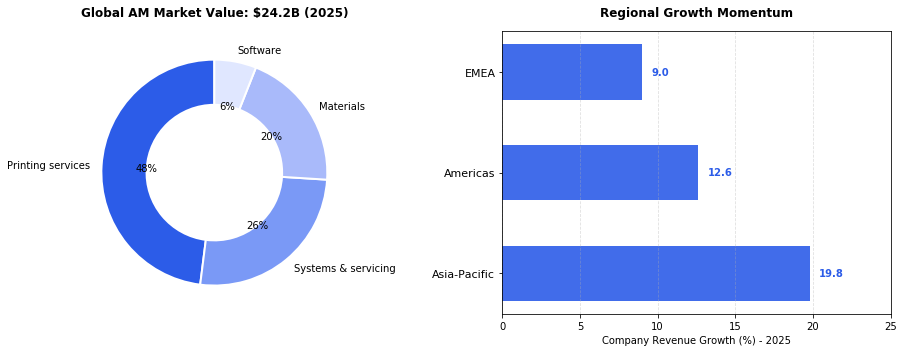

✓ Visualizations generated successfully.


In [10]:
# Visualization using matplotlib / pandas
try:
    import matplotlib.pyplot as plt
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    
    # 1. Market Segment Shares (Donut Chart)
    seg_names = [s["name"] for s in extracted_metrics["segments"]]
    seg_shares = [s["share"] for s in extracted_metrics["segments"]]
    colors = ["#2c5ce8", "#7a99f6", "#a9bafa", "#e0e7ff"]
    
    wedges, texts, autotexts = ax1.pie(
        seg_shares, 
        labels=seg_names, 
        autopct='%1.0f%%',
        startangle=90,
        colors=colors,
        wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2)
    )
    ax1.set_title(f"Global AM Market Value: ${extracted_metrics['revenue']}B (2025)", fontsize=12, fontweight='bold', pad=15)
    
    # 2. Regional Growth Rates (Horizontal Bar Chart)
    reg_names = [r["name"] for r in extracted_metrics["regions"]]
    reg_growths = [r["growth"] for r in extracted_metrics["regions"]]
    
    y_pos = range(len(reg_names))
    bars = ax2.barh(y_pos, reg_growths, color="#2c5ce8", height=0.55, edgecolor="none", alpha=0.9)
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(reg_names, fontsize=11)
    ax2.set_xlabel("Company Revenue Growth (%) - 2025", fontsize=10)
    ax2.set_title("Regional Growth Momentum", fontsize=12, fontweight='bold', pad=15)
    ax2.set_xlim(0, 25)
    ax2.grid(axis='x', linestyle='--', alpha=0.4)
    
    for bar in bars:
        width = bar.get_width()
        ax2.text(width + 0.6, bar.get_y() + bar.get_height()/2, f"{width}", va='center', fontsize=10, fontweight='bold', color="#2c5ce8")
        
    plt.tight_layout()
    plt.show()
    print("✓ Visualizations generated successfully.")
except ImportError:
    print("ℹ Matplotlib is not installed in this environment. Install with: pip install matplotlib")
    print("Summary of Scraped Metrics:")
    for s in extracted_metrics["segments"]:
        print(f"  - {s['name']}: {s['share']}%")
    for r in extracted_metrics["regions"]:
        print(f"  - {r['name']}: {r['growth']}%")